In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from striplog import Striplog

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data' / 'bow_valley' / 'cross_section'

In [15]:
df_collars = pd.read_csv(DATA / 'collars.csv')
cols = ['code', 'mp_elev_m', 'depth_str', 'aquifer', 'aquifer_lithology',
       'aquifer_type', 'production_str', 'well_depth_m', 'td_m', 'awwid_elev_m', 'well_use']
df_collars = df_collars[cols]
df_collars.set_index('code', inplace=True)

df_completions = pd.read_csv(DATA / 'completions.csv')
df_completions = df_completions.drop_duplicates(subset='code', keep='first')
cols = ['code', 'from_m', 'to_m', 'top_elev_m', 'base_elev_m', 'detail']
df_completions = df_completions[cols]
df_completions.set_index('code', inplace=True)

meta = df_collars.join(df_completions)

In [30]:
lith_intv = pd.read_csv(DATA / 'lithology_intervals.csv', index_col=0)
formation = {val: sub_df for val, sub_df in lith_intv.groupby('code')}

In [63]:
meta

,mp_elev_m,depth_str,aquifer,aquifer_lithology,aquifer_type,production_str,well_depth_m,td_m,awwid_elev_m,well_use,from_m,to_m,top_elev_m,base_elev_m,detail
code,,,,,,,,,,,,,,,
301,1603.125,12.20 m,Rocky Mountain,Sandstone,---,6.5 - 8.5,12.20,12.19,1612.66,Observation,6.50,8.50,1596.62,1594.62,Rocky Mountain
303,1668.041,36.58 m,Rocky Mountain,Sandstone,---,34 - 36.58,36.58,36.58,1668.78,Observation,34.00,36.58,1634.04,1631.46,Rocky Mountain
305,2067.549,11.58 m,Fernie,Shale,---,9 - 11.58,11.58,11.58,2069.03,Observation,9.00,11.58,2058.55,2055.97,Fernie
764,1378.093,59.10 m,Surficial,Sand & Gravel,---,36.6 - 54.9,59.10,60.96,1380.07,Observation,36.58,54.86,1341.51,1323.23,NaN
364,1284.610,33.80 m,Buried Valley,Gravel,Confined,21.94 - 29.56,33.80,33.83,1284.78,Observation,21.94,29.56,1262.67,1255.05,Buried Valley
759,1291.795,219.50 m,Calgary Valley,Clay & Gravel,Confined,195.1 - 201.2,219.50,219.46,1291.84,Observation,195.10,201.20,1096.70,1090.60,Calgary Valley
386,1640.000,12.80 m,Surficial,Gravel & Clay,---,0 - 12.8,12.80,12.80,NaN,Observation,0.00,12.80,1640.00,1627.20,Surficial
931,1509.849,30.48 m,Surficial,Gravel,Unconfined,23.2 - 29.3,30.48,30.48,1510.31,Domestic,23.16,29.26,1486.69,1480.59,"dia 0.25"""
760,1315.463,85.30 m,Calgary Valley,Clay & Gravel,Unconfined,59.4 - 62.5,85.30,85.34,NaN,Observation,59.40,62.50,1256.06,1252.96,Calgary Valley


In [32]:
materials = set()
for well, df in formation.items():
    materials.update(df['material'].unique())

In [33]:
descs = set()
for well, df in formation.items():
    descs.update(df['description'].unique())

In [34]:
descs

{'Calcareous',
 'Carbonaceous',
 'Coarse Grained',
 'Fine Grained',
 'Gravelly',
 'Medium Grained',
 'Sandy',
 'Silty',
 nan}

In [58]:
hatch_map = {
    'Calcareous': 'x',
    'Carbonaceous': '|',
    'Coarse Grained': '.',
    'Medium Grained': '..',
    'Fine Grained': '...',
    'Gravelly': 'o',
    'Sandy': '/',
    'Silty': '\\',
}

In [54]:
palette = {
    # rock / bedrock types — cool hues, free from the warm cluster below
    'Bedrock':    '#7A6B99',
    'Coal':       '#1C1C1C',
    'Limestone':  '#6EC6CA',
    'Rocks':      '#9E9E9E',
    'Shale':      '#4A5568',

    # clay-dominated — green family
    'Clay':          '#5B8C5A',
    'Clay & Sand':   '#A9AD5E',
    'Clay & Gravel': '#6B5D3F',

    # unconsolidated warm cluster — hardest to separate by hue alone,
    # spread deliberately across lightness/saturation, not just hue
    'Sand':               '#F4D35E',
    'Sand & Gravel':      '#EFAE4D',
    'Sandstone & Gravel': '#C89550',
    'Gravel':             '#E0793D',
    'Gravel & Boulders':  '#A85236',
    'Till':               '#8A5A34',

    # bridging rock/unconsolidated mixes
    'Shale & Gravel': '#6E6B62',
    'Till & Rocks':   '#A08D74',
}

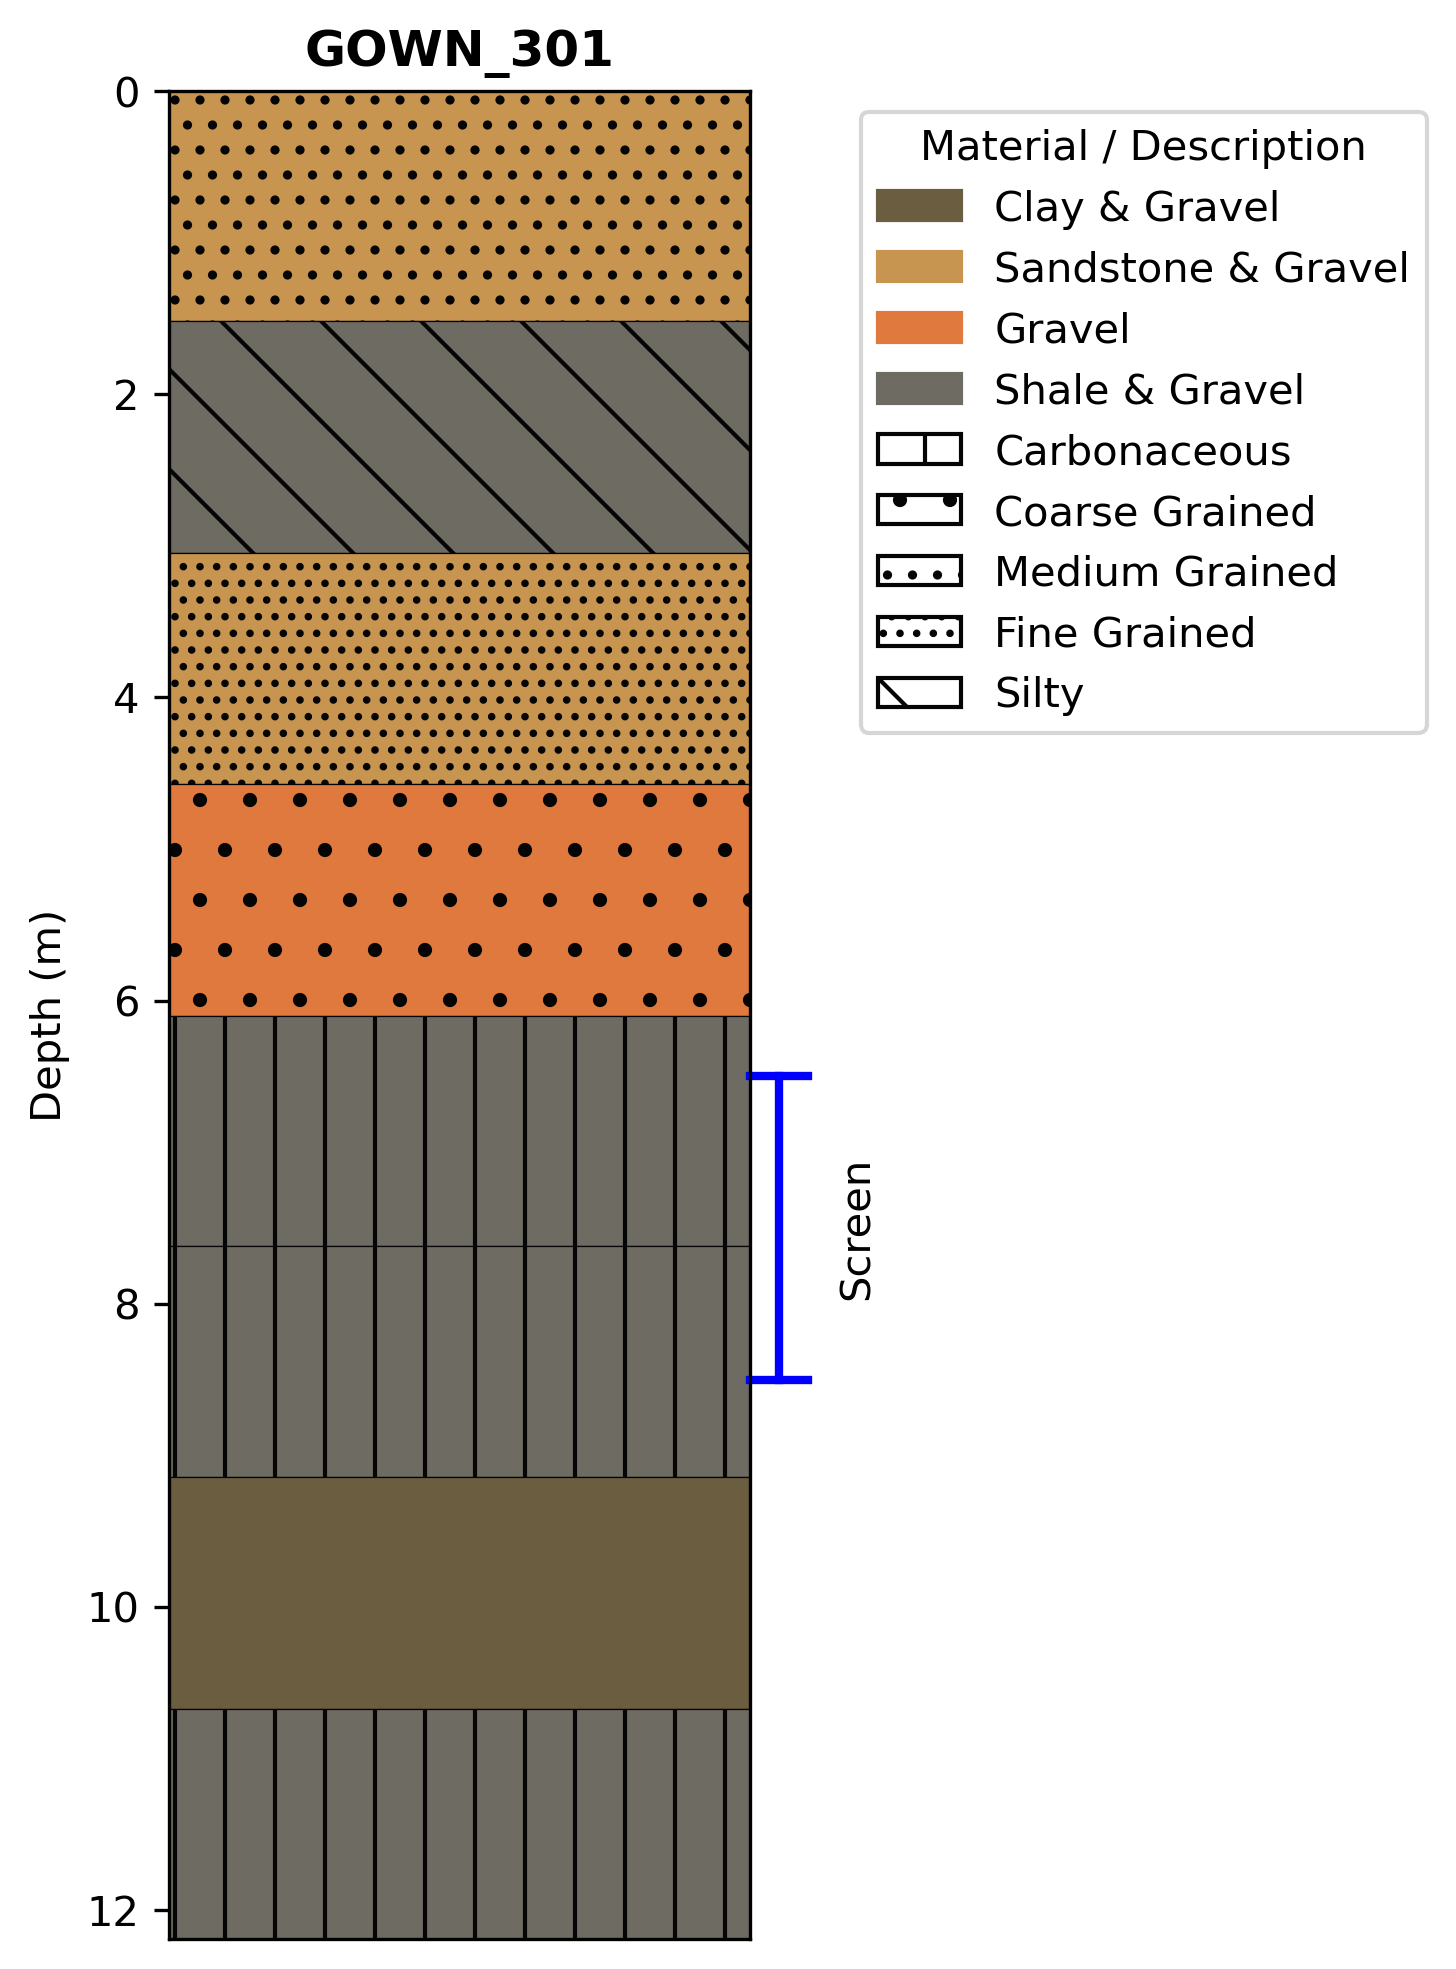

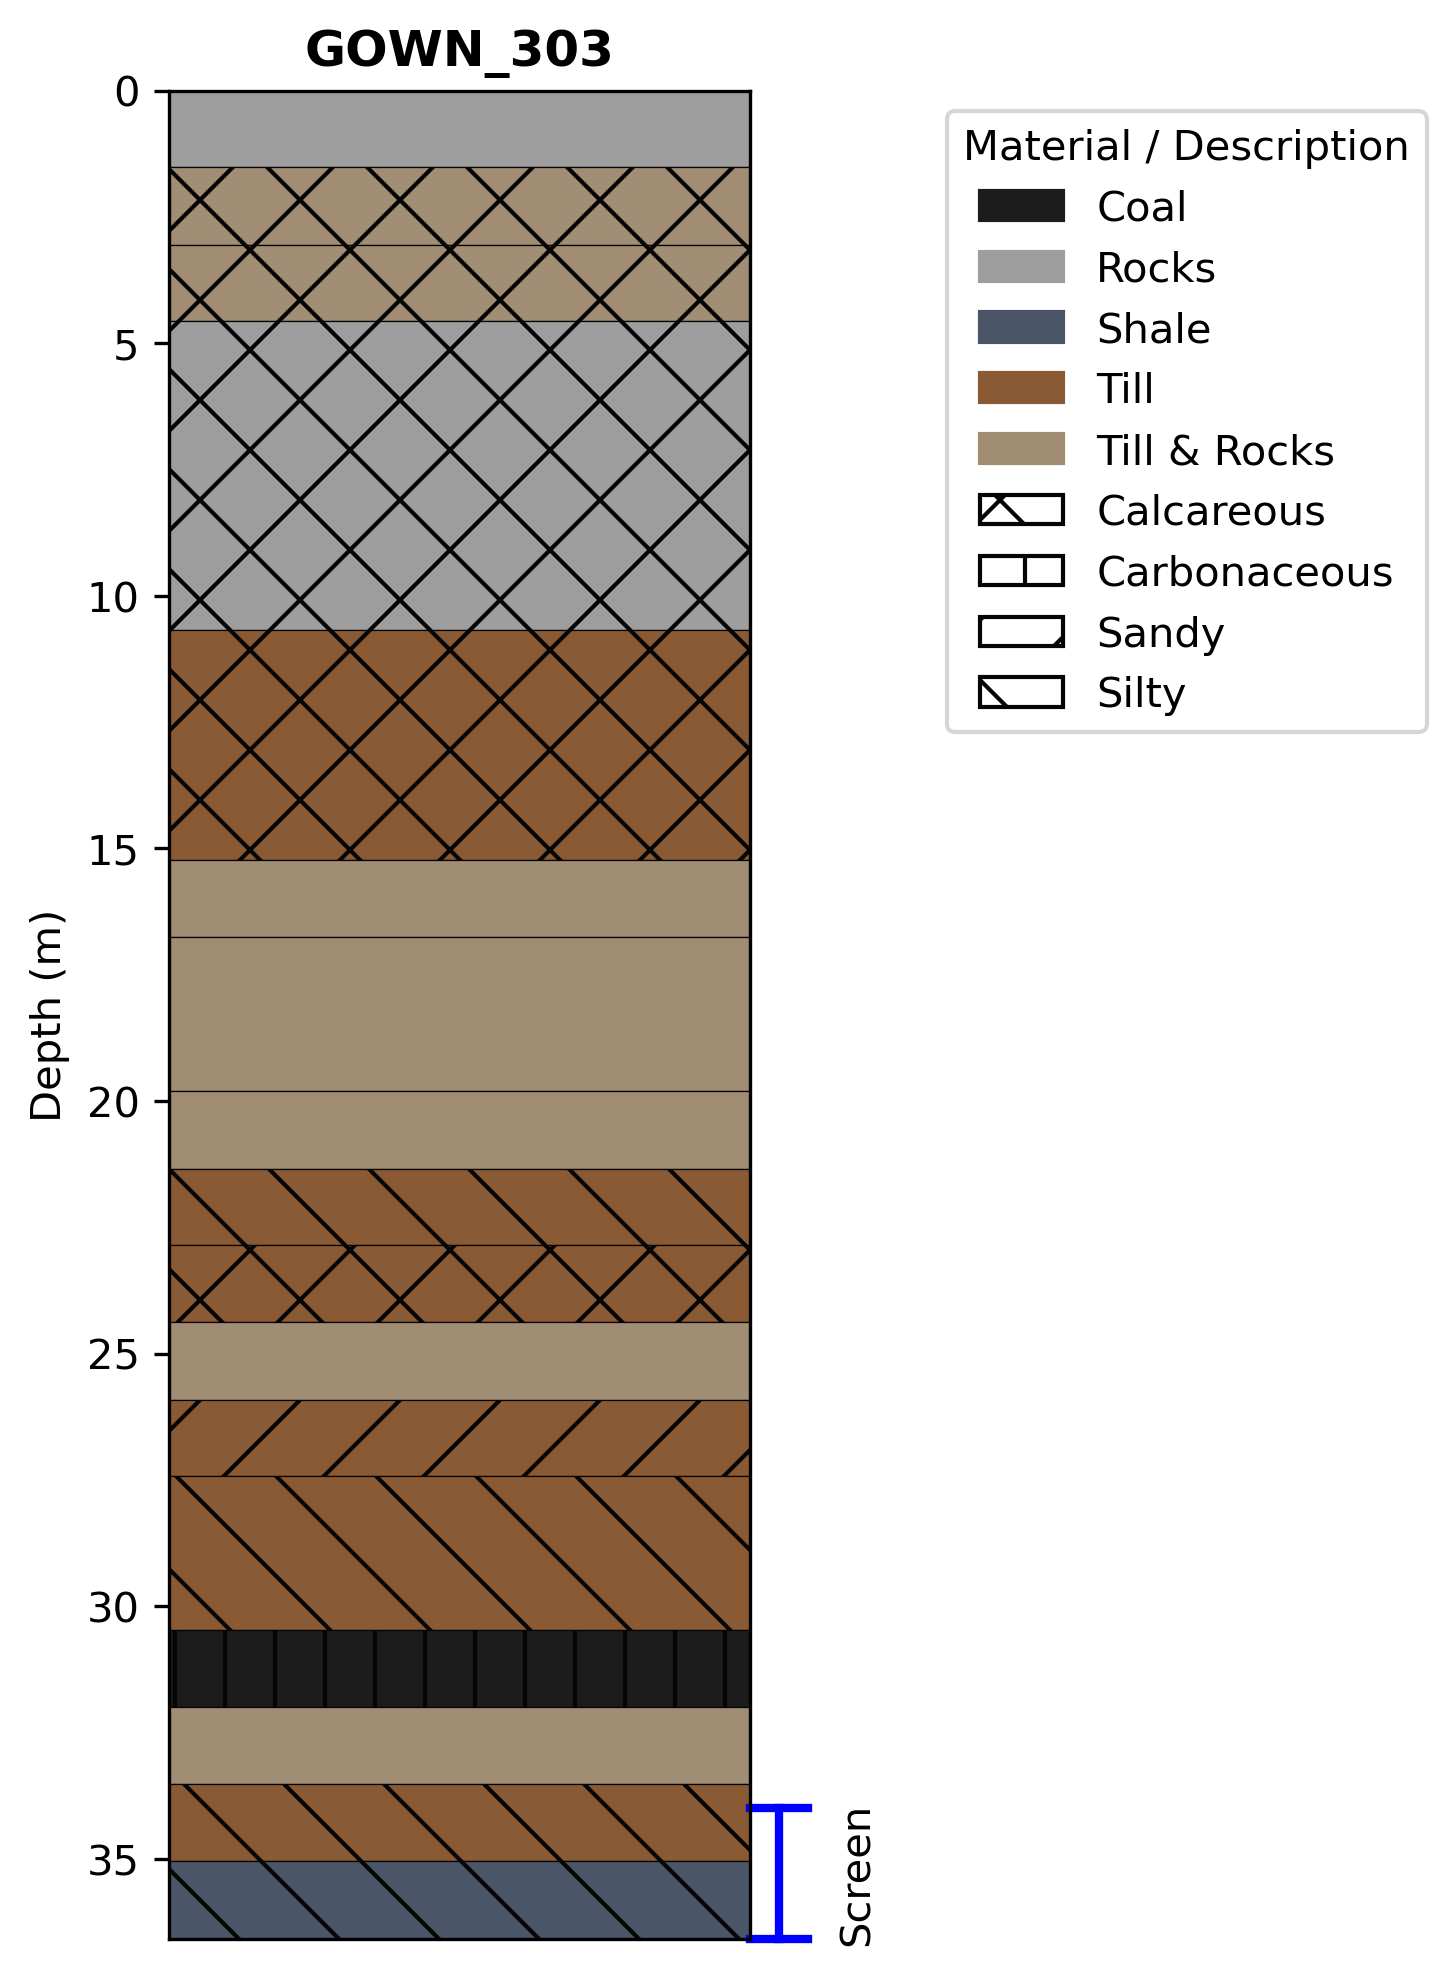

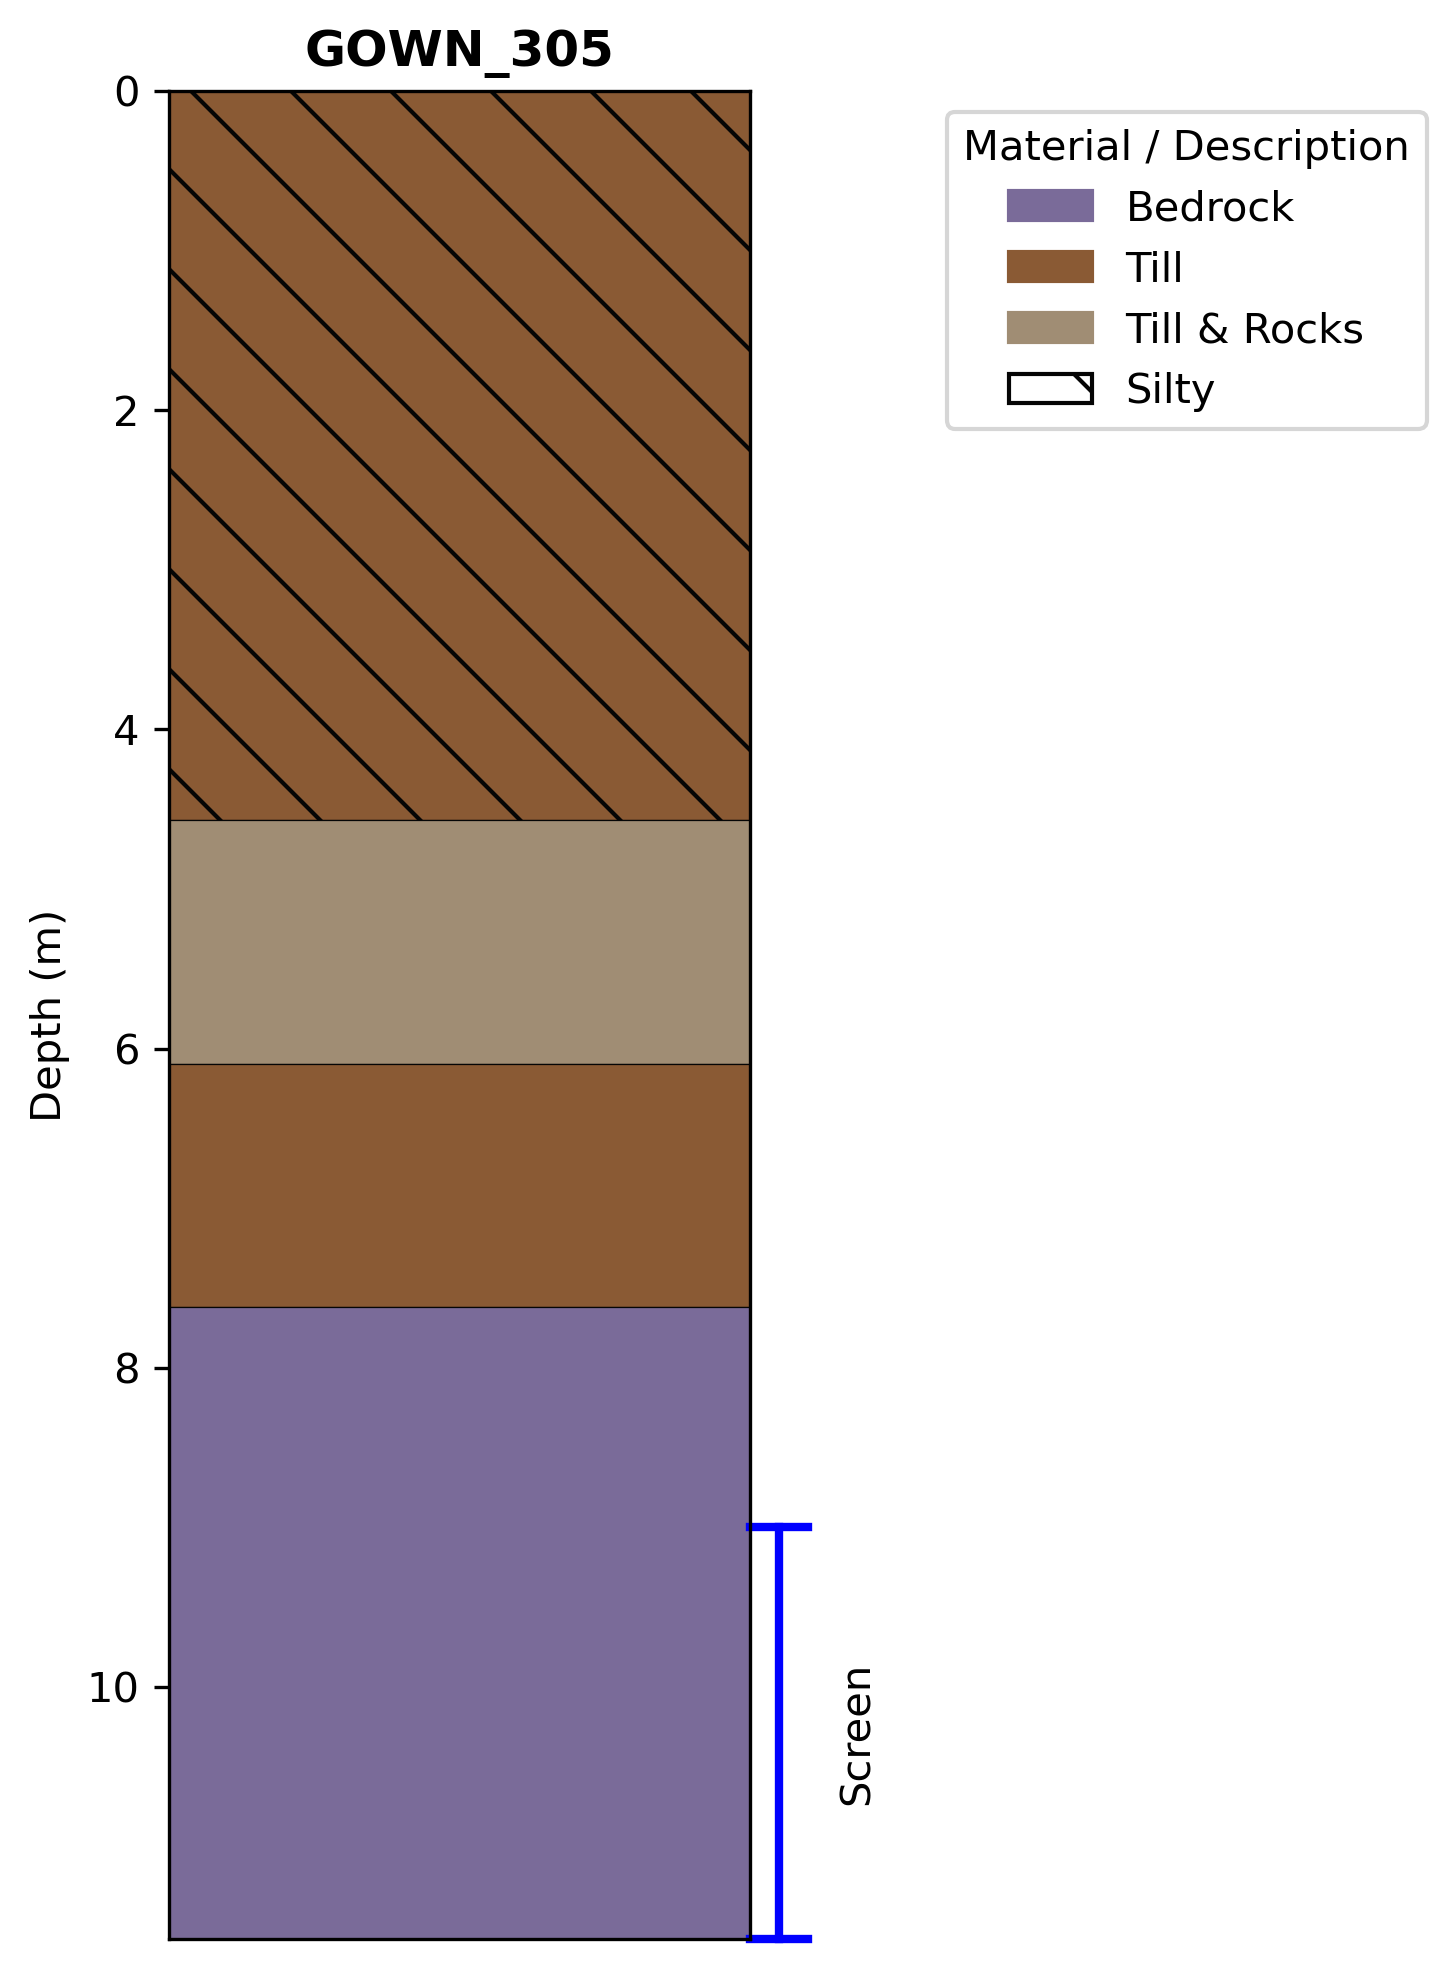

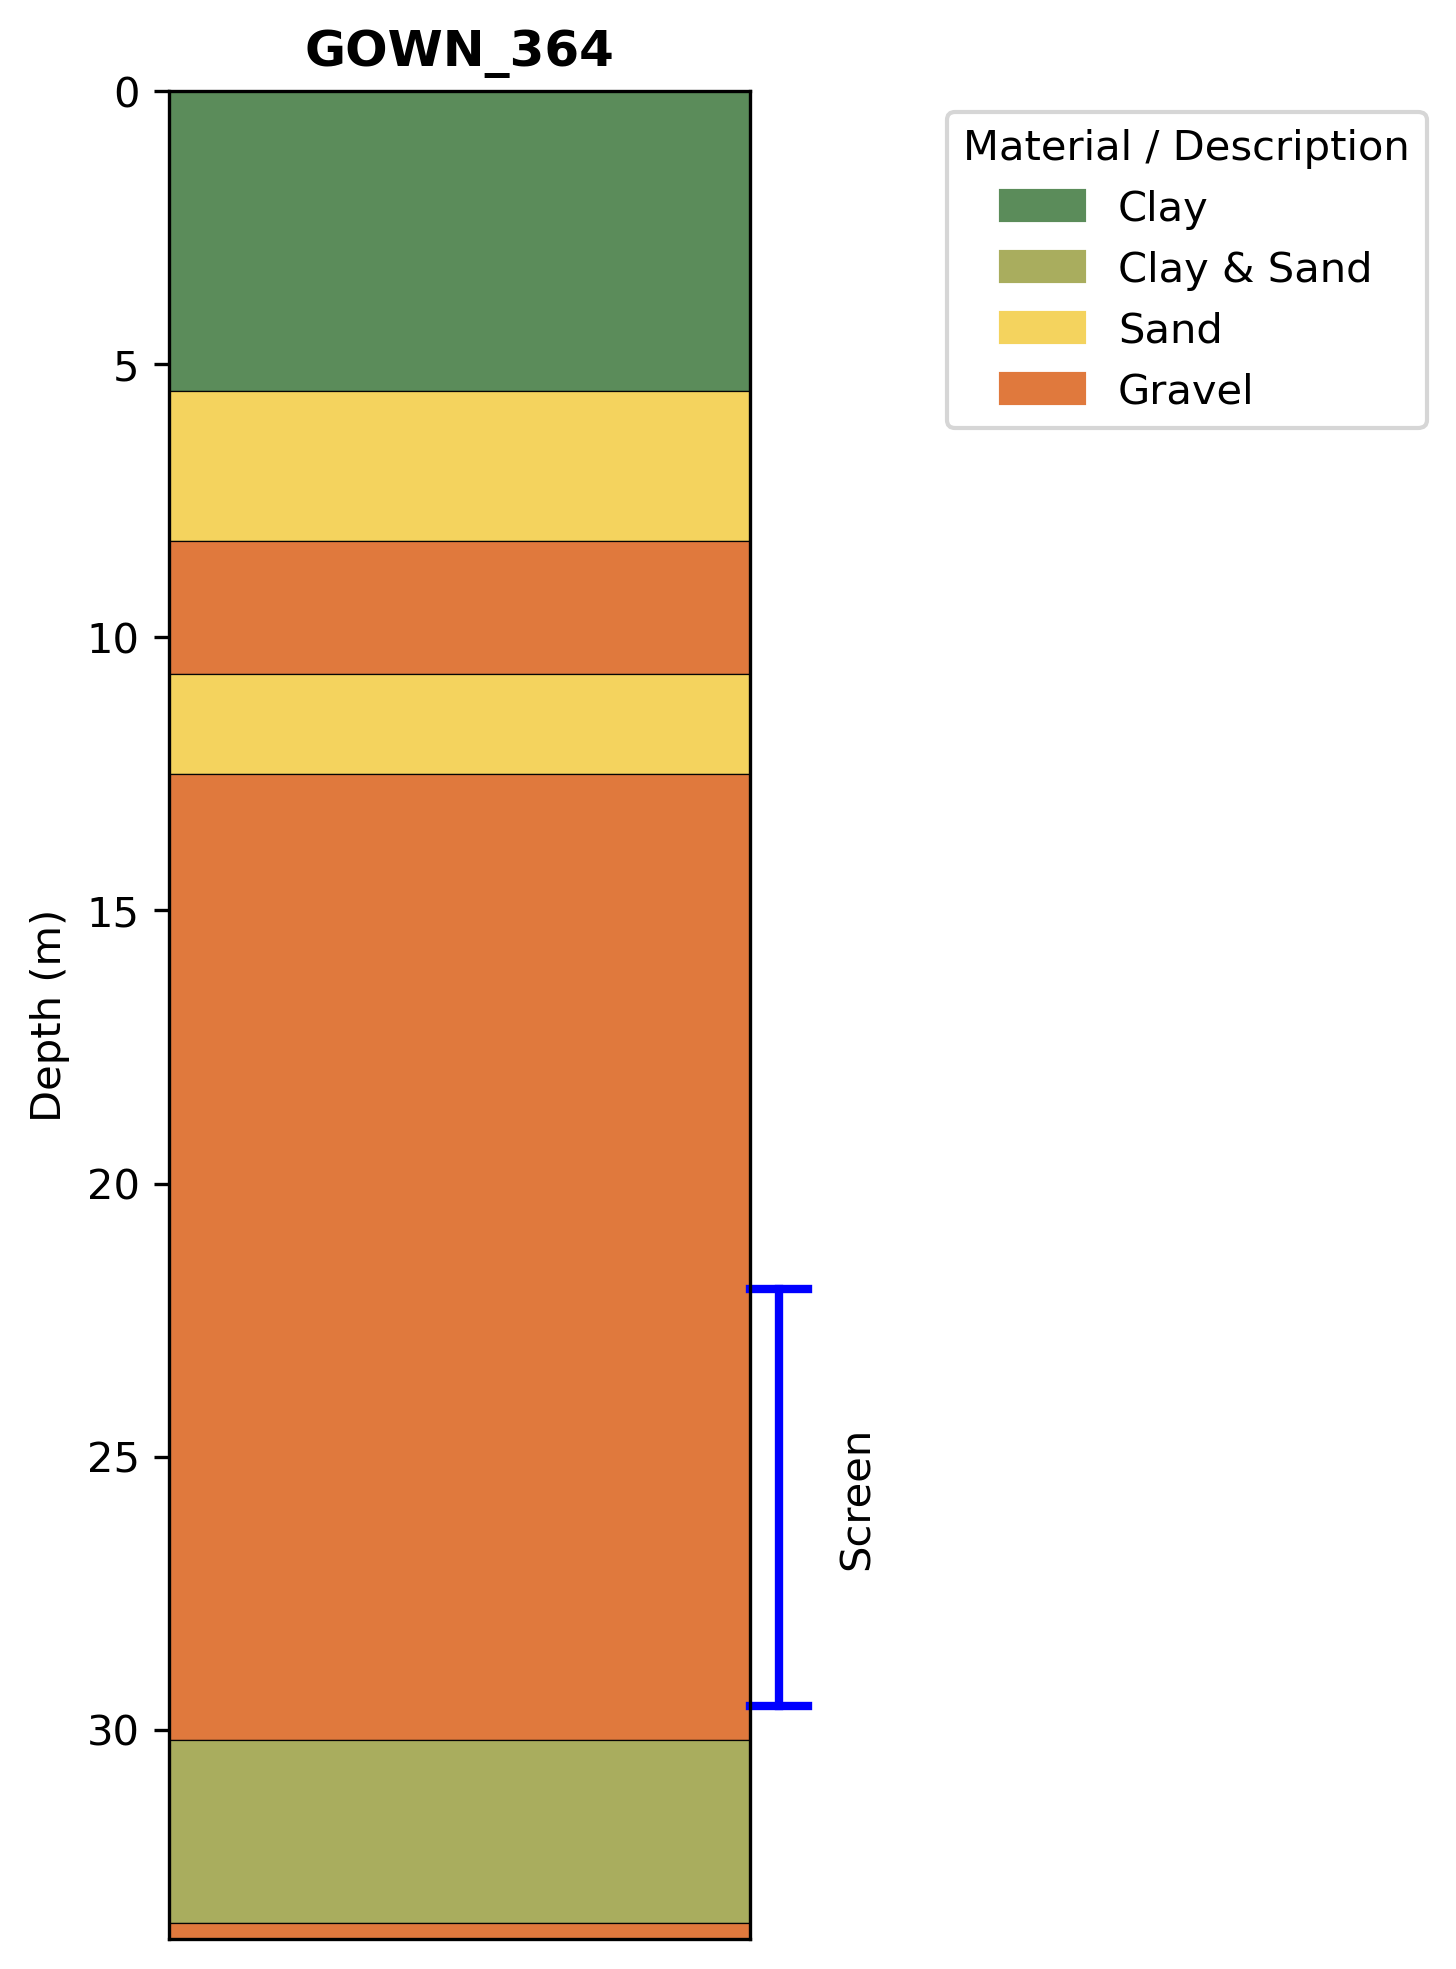

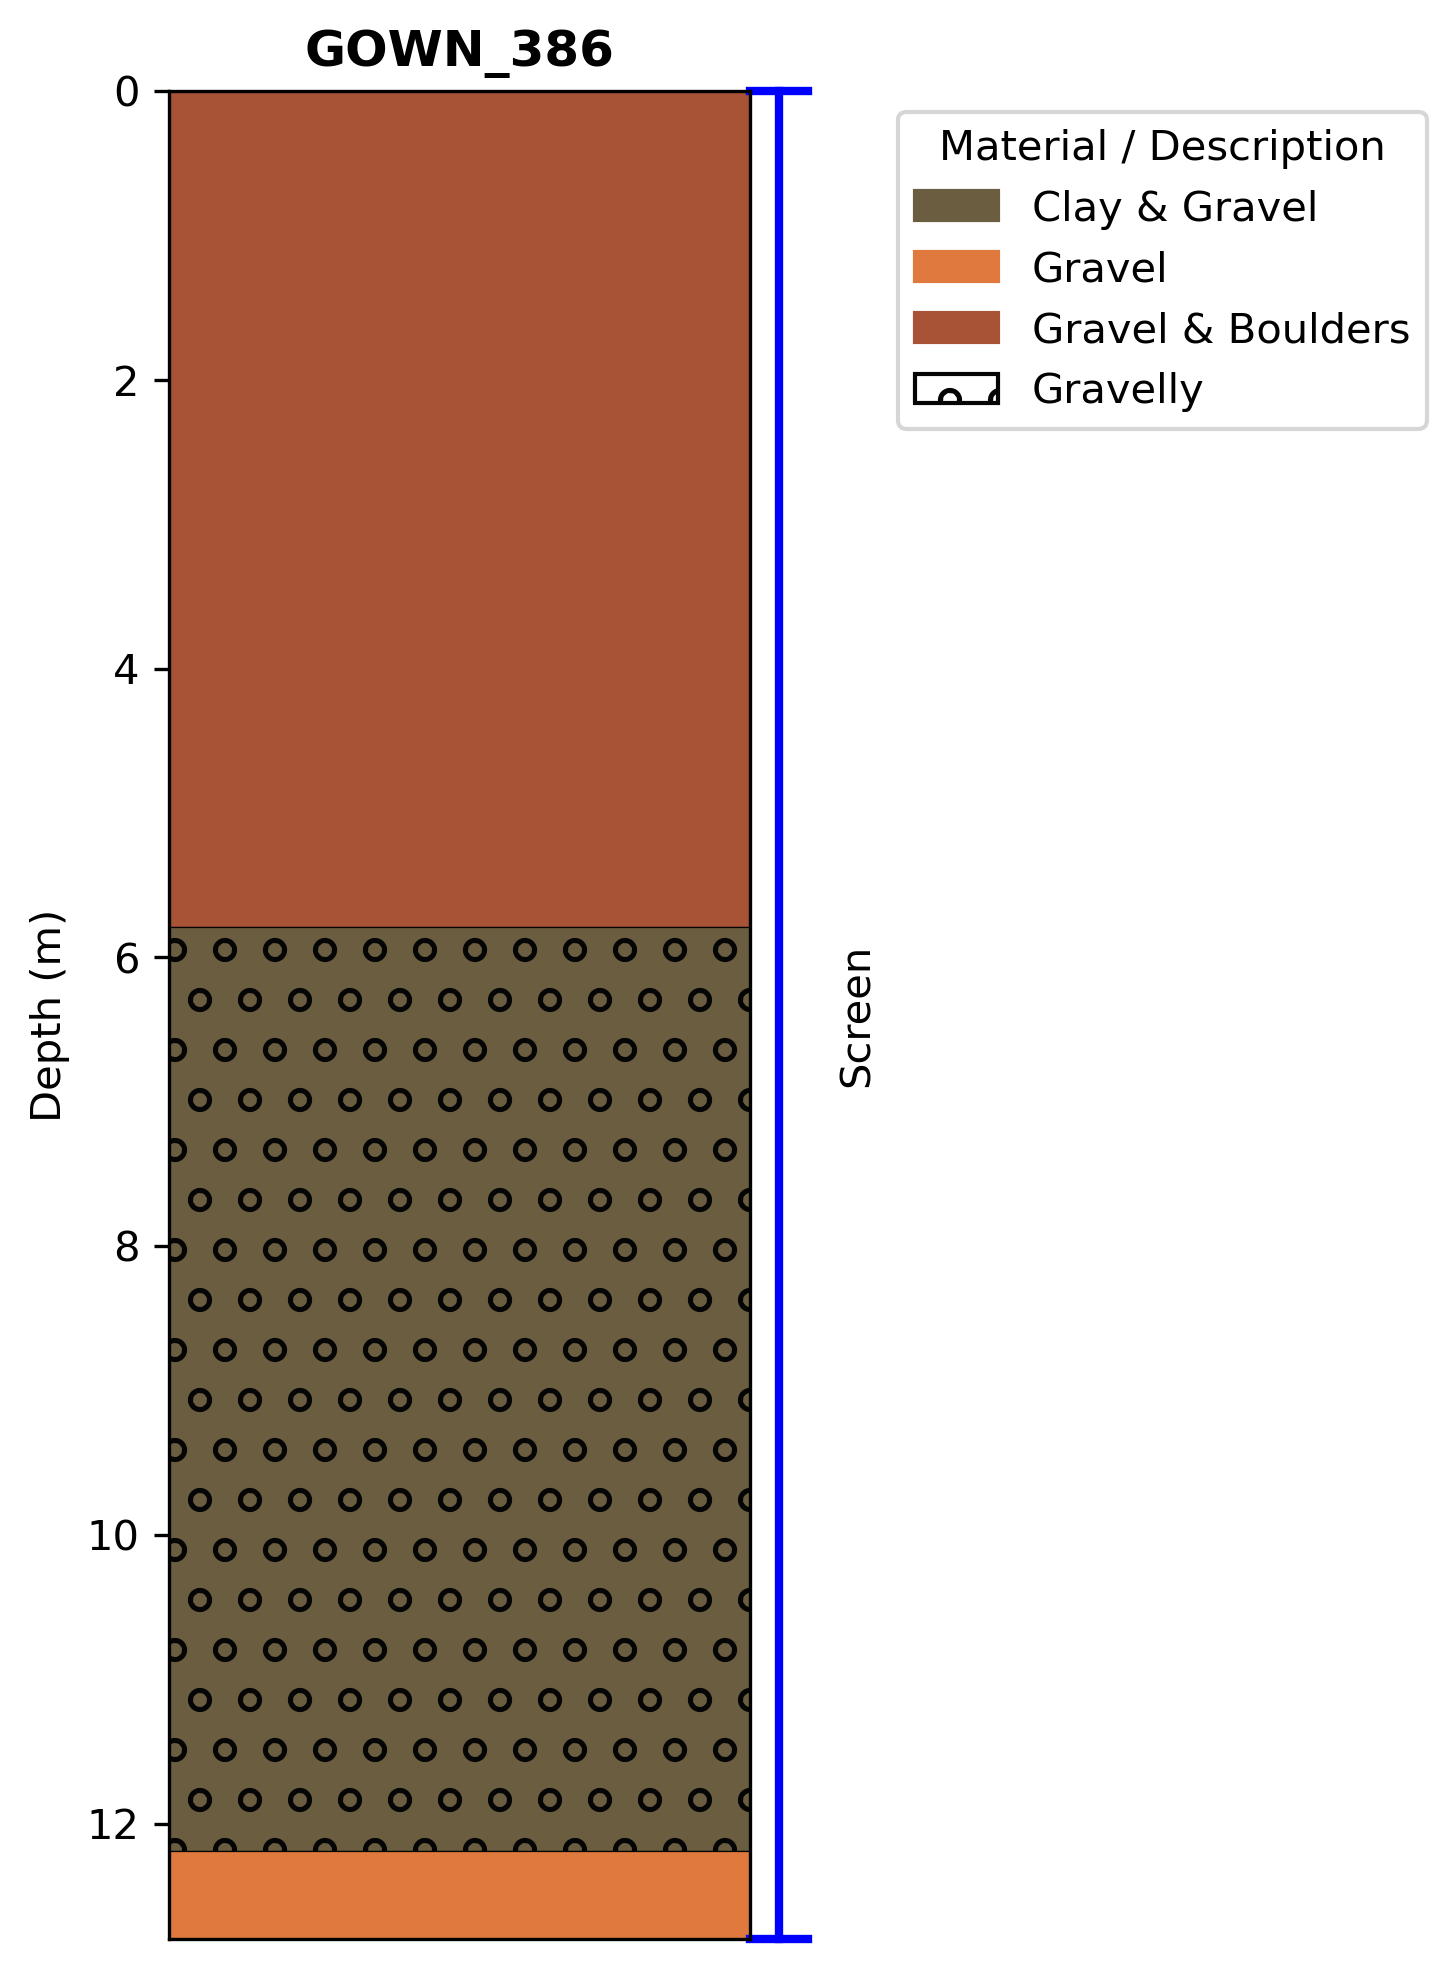

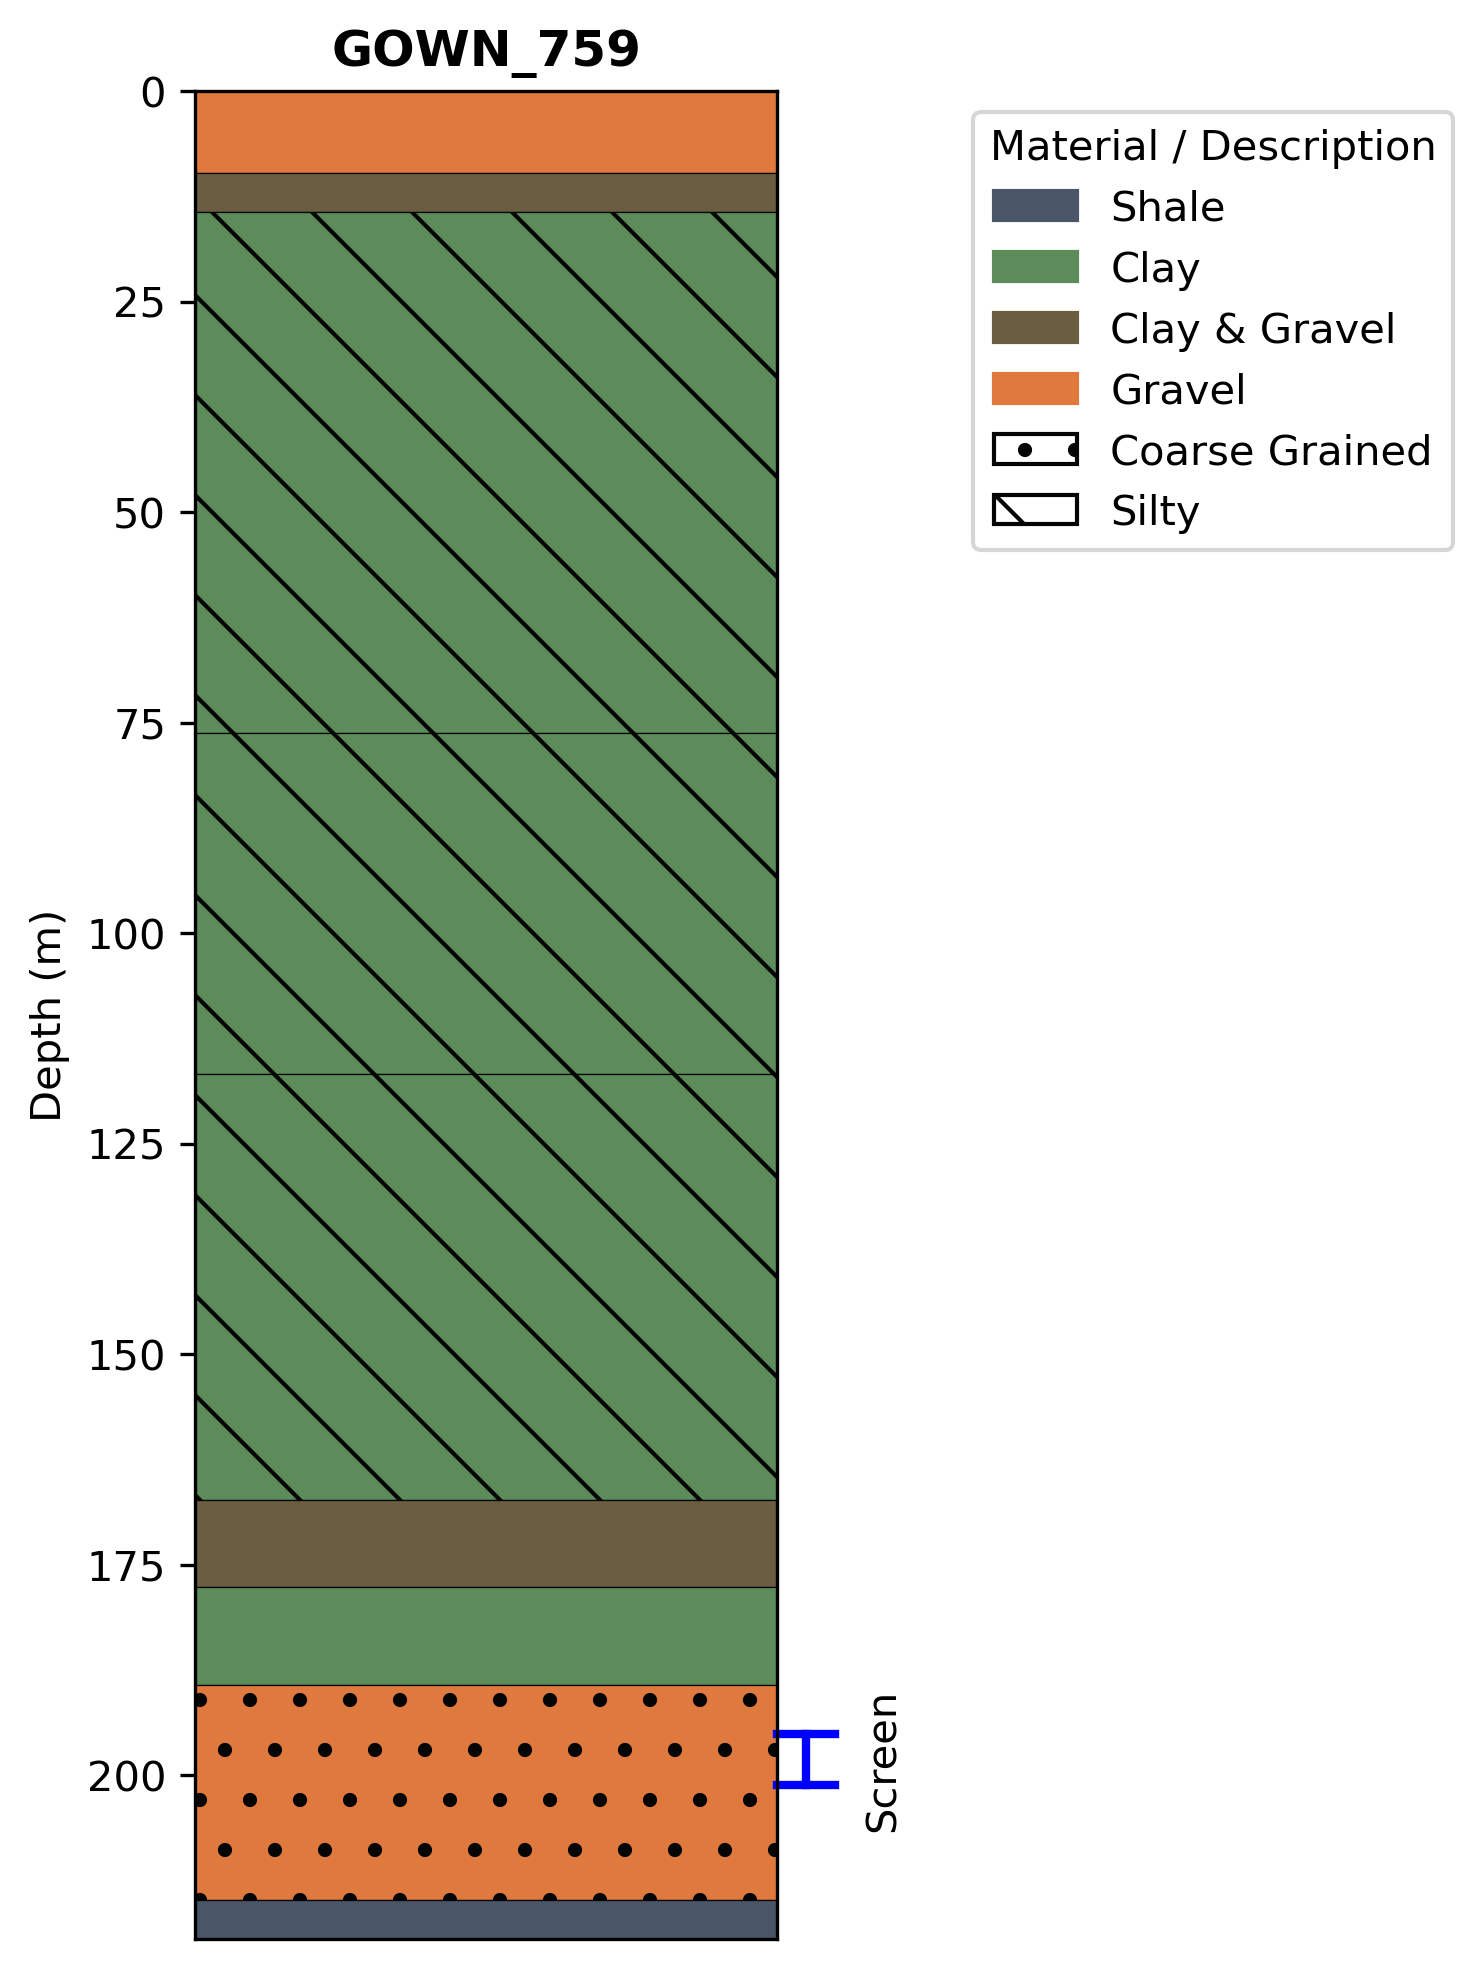

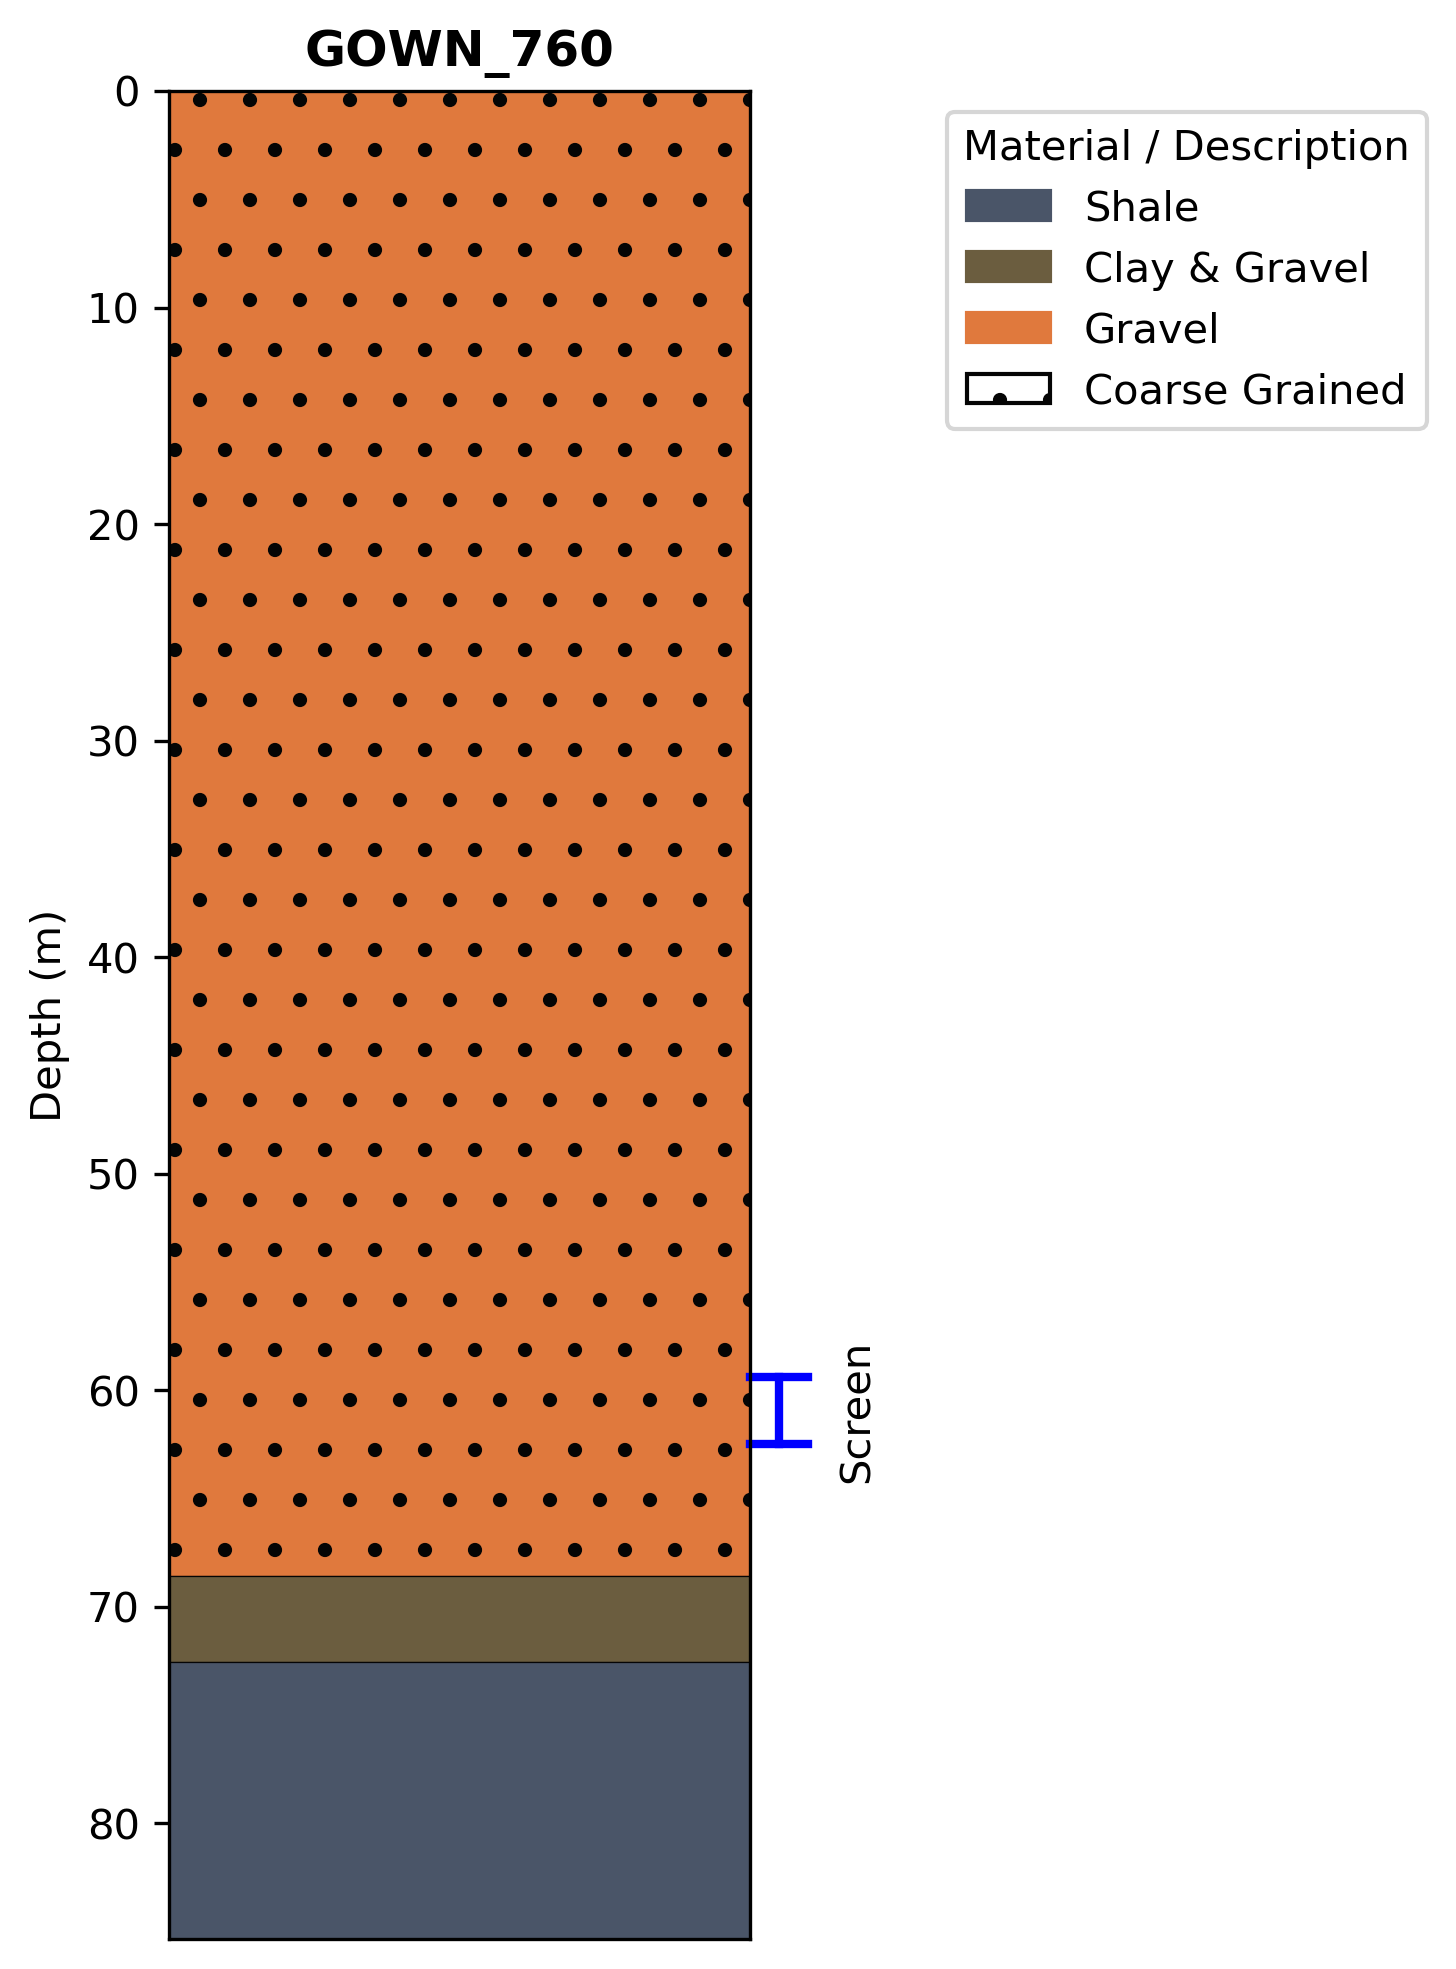

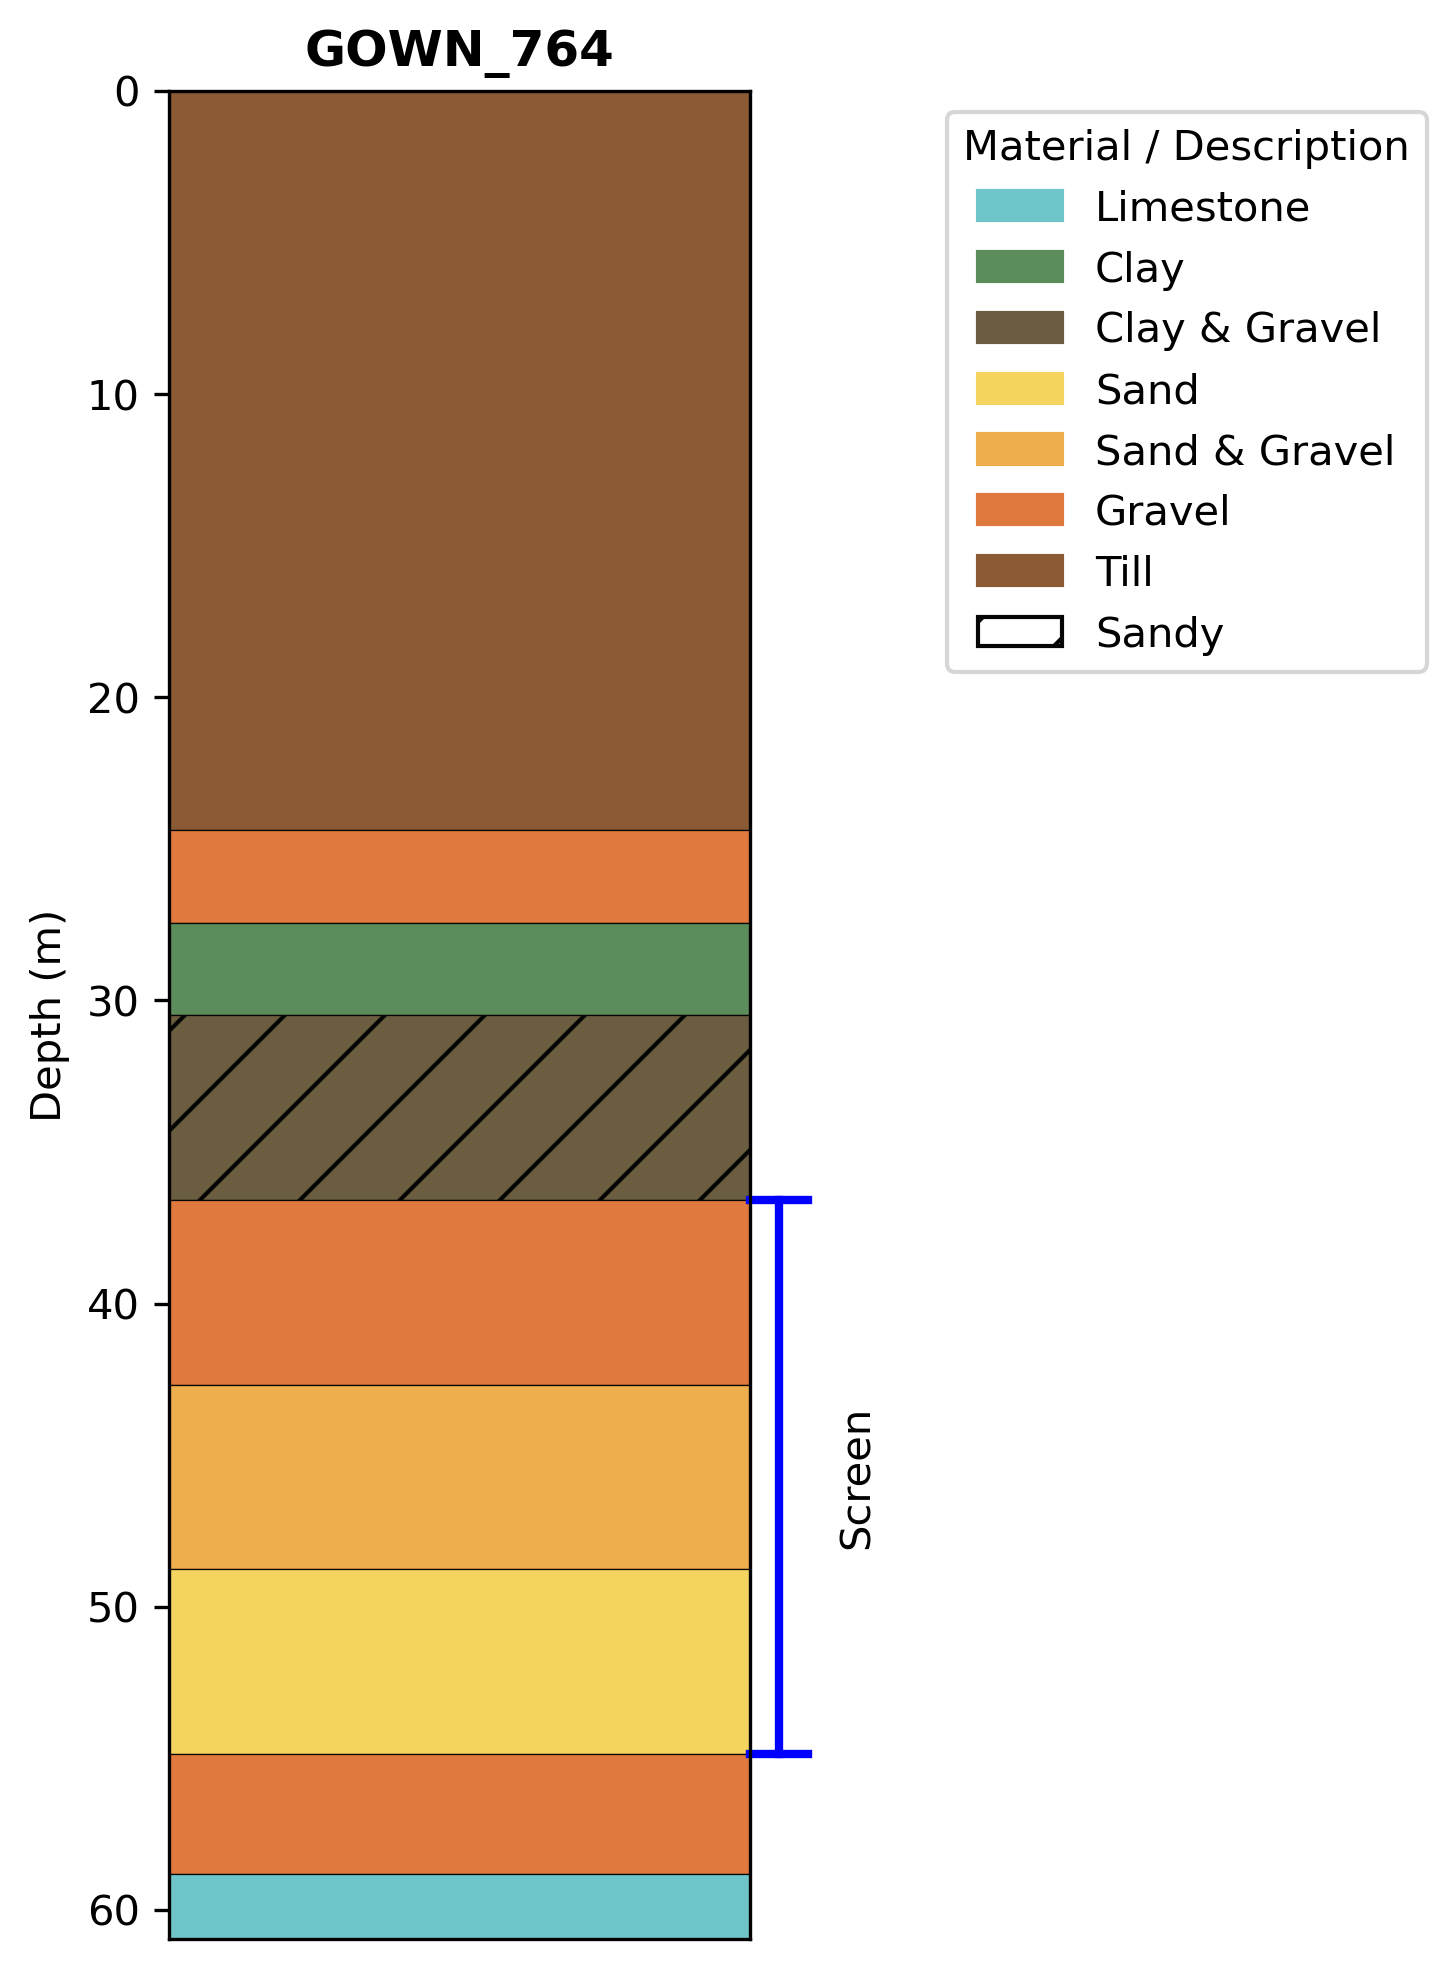

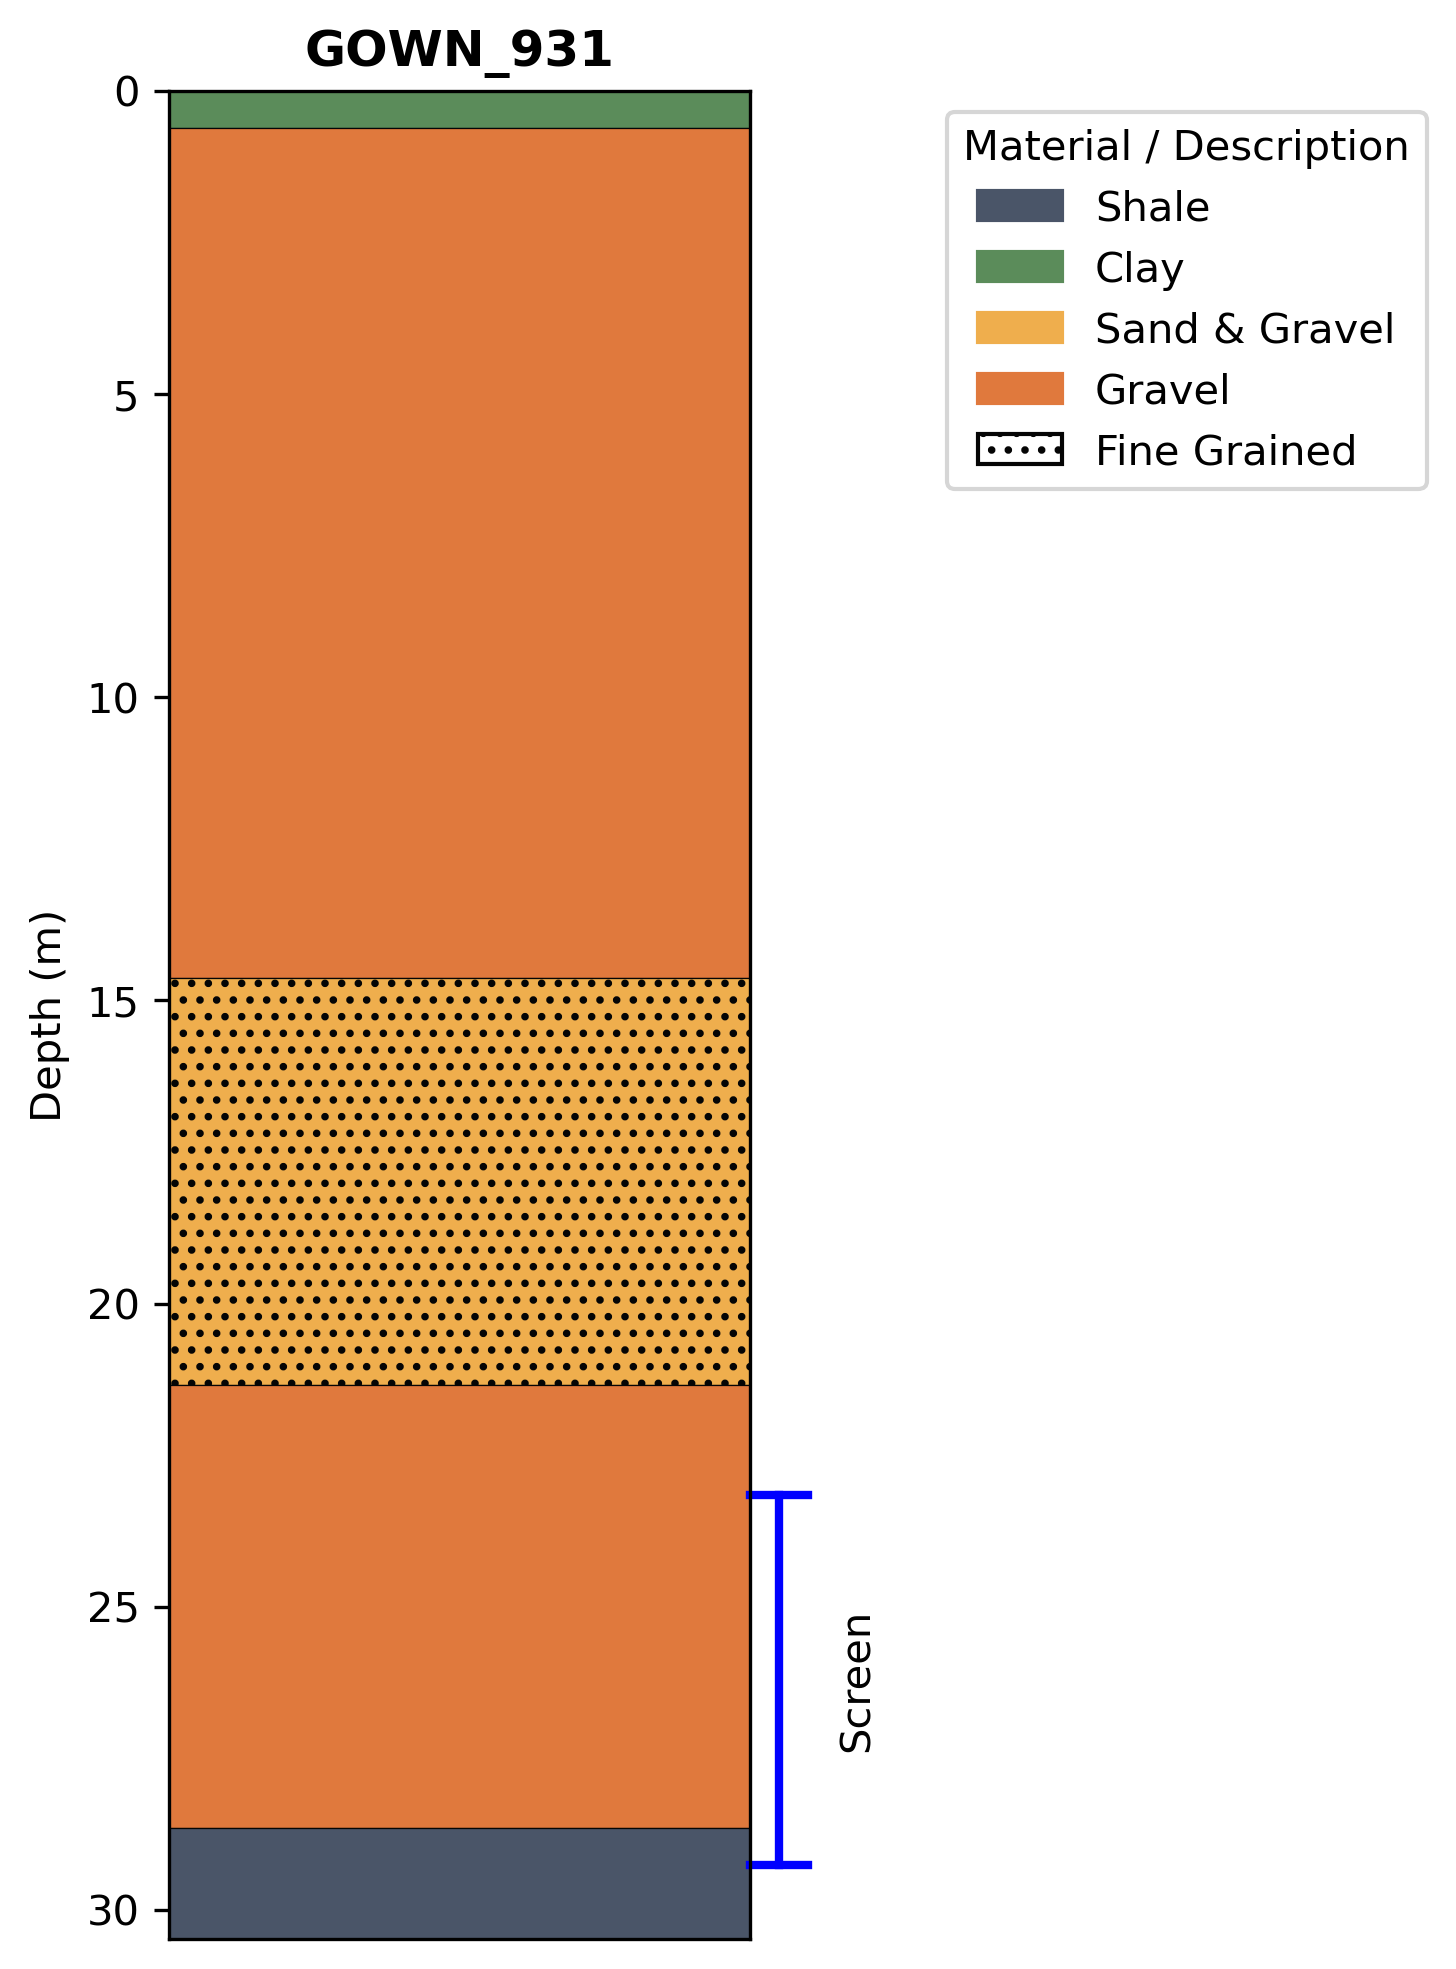

In [64]:
for well, df in formation.items():
    depth_top = df['from_m'].values
    depth_base = df['to_m'].values
    lithology = df['material'].values
    desc = df['description'].values

    screen_top = meta.loc[well]['from_m']
    screen_base = meta.loc[well]['to_m']


    fig, ax = plt.subplots(figsize=(2.5, 8), dpi=300)

    ax.plot([1.05, 1.05], [screen_top, screen_base], color='blue', lw=2, clip_on=False)
    ax.plot([1.0, 1.1], [screen_top, screen_top], color='blue', lw=2, clip_on=False)
    ax.plot([1.0, 1.1], [screen_base, screen_base], color='blue', lw=2, clip_on=False)
    ax.text(1.15, (screen_top + screen_base) / 2, 'Screen',
            rotation=90, va='center', ha='left', clip_on=False)

    for top, base, lith, d in zip(depth_top, depth_base, lithology, desc):
        ax.fill_betweenx(
            [top, base], 0, 1,
            color=palette[lith],
            hatch=hatch_map.get(d),
            edgecolor="#050505", linewidth=0.3
        )

    ax.set_ylim(depth_base.max(), depth_top.min())  # depth increases downward
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_ylabel('Depth (m)')

    # Legend
    used = set(lithology)
    material_handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items() if l in used]

    used_desc = set(desc)
    desc_handles = [mpatches.Patch(facecolor='none', edgecolor='#050505', hatch=h, linewidth=1, label=d) for d, h in hatch_map.items() if d in used_desc]

    ax.legend(handles=material_handles+desc_handles, loc='upper right', bbox_to_anchor=(2.2, 1), title='Material / Description')

    plt.title(f"GOWN_{well}", fontweight='bold')
    plt.show()